In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# **Load data**

In [3]:
# train = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
# test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (1460, 81)
Test Shape:  (1459, 80)


In [4]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


<Axes: xlabel='SalePrice', ylabel='Count'>

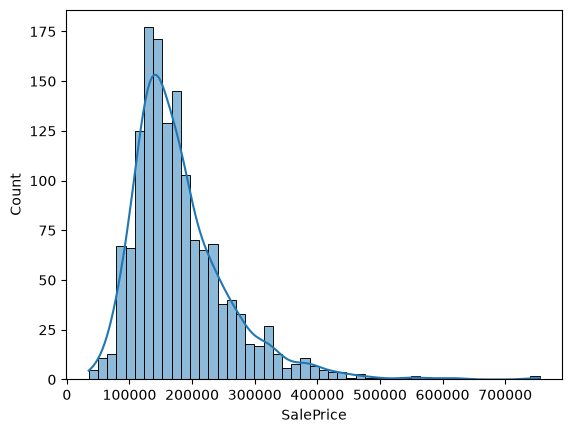

In [6]:
sns.histplot(train['SalePrice'], kde=True)

# **Check for NULL values <br>Train data**

In [7]:
print(train.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [8]:
train.duplicated().sum()

np.int64(0)

<Axes: >

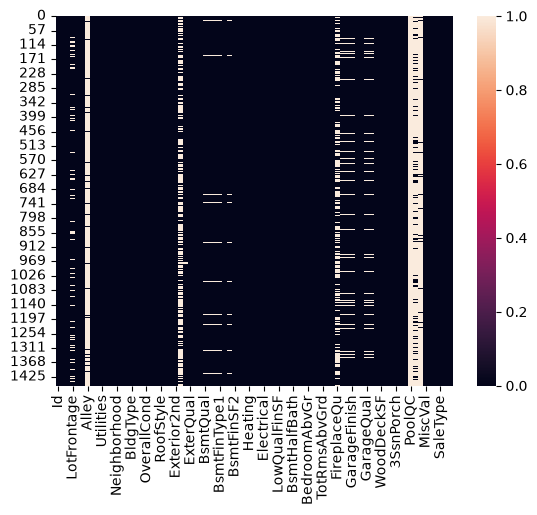

In [9]:
sns.heatmap(train.isnull())

# **Test data**

In [10]:
print(test.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


<Axes: >

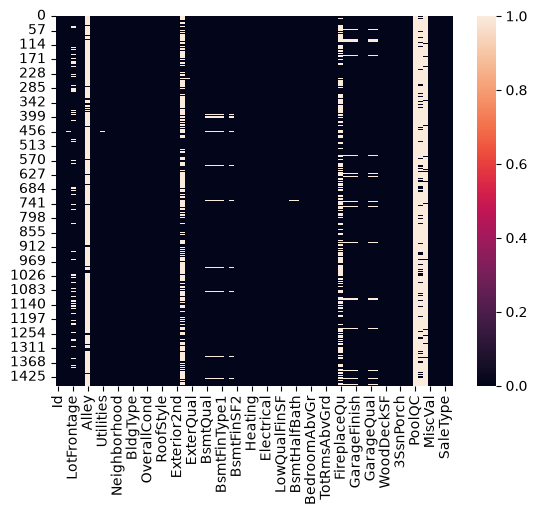

In [11]:
sns.heatmap(test.isnull())

# **For train data**

In [12]:
cat_col_train = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 
                 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
                 'GarageQual', 'GarageCond']
ncat_col_train = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

for i in cat_col_train:
    train[i] = train[i].fillna(train[i].mode()[0])

for j in ncat_col_train:
    train[j] = train[j].fillna(train[j].mean())

# **For test data**

In [13]:
cat_col_test = ['FireplaceQu', 'GarageType', 'GarageFinish', 'MasVnrType', 'BsmtQual', 
                'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
               'GarageQual', 'GarageCond', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']

ncat_col_test = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
                'BsmtHalfBath', 'GarageCars', 'GarageArea']

for i in cat_col_test:
    test[i] = test[i].fillna(test[i].mode()[0])

for j in ncat_col_test:
    test[j] = test[j].fillna(test[j].mean())

# **Drop columns**

In [14]:
to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']

for k in to_drop:
    train.drop([k], axis = 1, inplace = True)
    test.drop([k], axis = 1, inplace = True)

<Axes: >

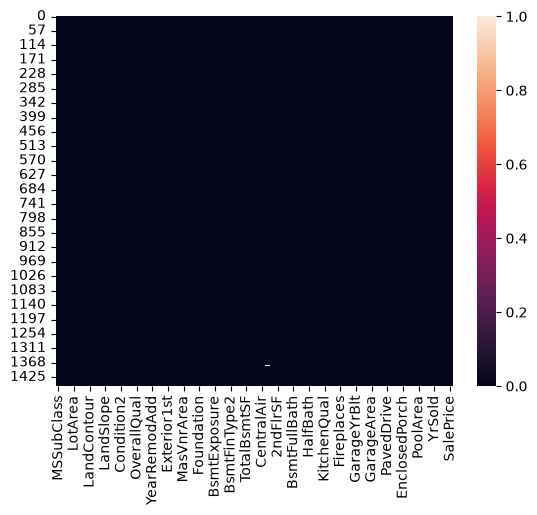

In [15]:
sns.heatmap(train.isnull())

<Axes: >

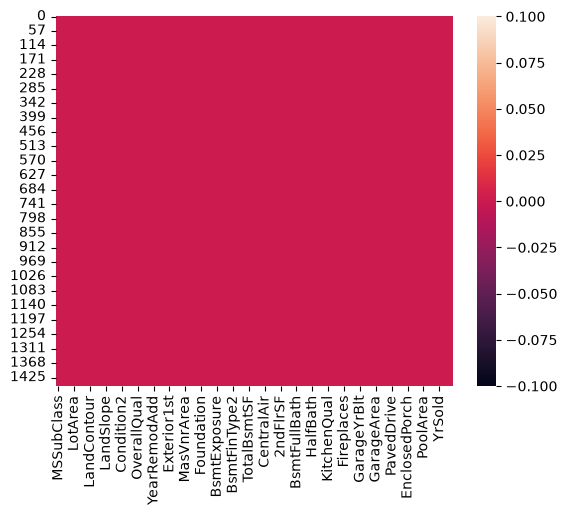

In [16]:
sns.heatmap(test.isnull())

In [17]:
print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


In [18]:
final_df = pd.concat([train, test], axis = 0)
final_df.shape

(2919, 76)

In [19]:
all_cat_col = ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 
              'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
              'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
              'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 
              'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
               'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields)
        df1 = pd.get_dummies(final_df[fields], drop_first = True)

        final_df.drop([fields], axis = 1, inplace = True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis = 1)
        i = i + 1
    df_final = pd.concat([final_df, df_final], axis = 1)

    return df_final

final_df = cat_onehot_encoding(all_cat_col)

MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition


In [20]:
final_df.shape

(2919, 236)

In [21]:
final_df = final_df.loc[:, ~final_df.columns.duplicated()]
final_df.shape

(2919, 176)

In [22]:
df_train = final_df.iloc[:1460, :]
df_test = final_df.iloc[1460:, :]

df_test.drop(['SalePrice'], axis = 1)

print("Train Shape: ", df_train.shape)
print("Test Shape: ", df_test.shape)

Train Shape:  (1460, 176)
Test Shape:  (1459, 176)


# **Training data**

In [23]:
x_train = df_train.drop(['SalePrice'], axis = 1)
y_train = df_train['SalePrice']

# **Linear Regression**

In [24]:
from sklearn.linear_model import LinearRegression
import time

lr_model = LinearRegression()
start = time.time()
lr_model.fit(x_train, y_train)
training_time = round(time.time() - start, 2)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_train_pred = lr_model.predict(x_train)

mae = mean_absolute_error(y_train, y_train_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 16,596.86
RMSE : 26,352.19
R²   : 0.8899


In [26]:
# print("Hệ số (coefficients):", lr_model.coef_)
# print("Hệ số chặn (intercept):", lr_model.intercept_)
coef_df = pd.DataFrame({
    "feature": x_train.columns,
    "coefficient": lr_model.coef_
}).sort_values(by="coefficient", ascending=False)

print(coef_df.head(10))   # 10 feature ảnh hưởng dương mạnh nhất
print(coef_df.tail(10))   # 10 feature ảnh hưởng âm mạnh nhất

     feature    coefficient
108  WdShngl  149635.892539
102  CompShg   65847.890524
75   StoneBr   57705.268353
69   NridgHt   46413.504979
68   NoRidge   43996.078688
107  WdShake   43567.588663
156  Basment   32235.368858
36        FV   31034.077428
38        RL   31005.391438
37        RH   28932.599498
     feature   coefficient
106  Tar&Grv -34681.332472
103  Membran -42234.849532
144     OthW -48185.650474
47    NoSeWa -63991.072561
104    Metal -70927.662865
101     Shed -78914.853618
100  Mansard -83713.439861
98   Gambrel -90897.267814
99       Hip -91813.442042
97     Gable -96125.201475


In [27]:
param = {
    "fit_intercept": [True, False],  
    "positive": [True, False],       
    "copy_X": [True, False],      
}

In [28]:
from sklearn.model_selection import RandomizedSearchCV
 
random_cv = RandomizedSearchCV(
    estimator=lr_model,
    param_distributions=param,
    cv=5,
    n_iter=8,
    scoring="neg_mean_absolute_error",
    n_jobs=4,
    verbose=5,
    return_train_score=True,
    random_state=42,
)
random_cv.fit(x_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 2/5] END copy_X=True, fit_intercept=True, positive=True;, score=(train=-16290.149, test=-19650.777) total time=   0.0s
[CV 1/5] END copy_X=True, fit_intercept=True, positive=True;, score=(train=-16513.153, test=-23197.153) total time=   0.0s
[CV 3/5] END copy_X=True, fit_intercept=True, positive=True;, score=(train=-16044.507, test=-18791.656) total time=   0.0s
[CV 4/5] END copy_X=True, fit_intercept=True, positive=True;, score=(train=-16540.654, test=-18378.817) total time=   0.0s
[CV 5/5] END copy_X=True, fit_intercept=True, positive=True;, score=(train=-16043.737, test=-21644.121) total time=   0.0s
[CV 1/5] END copy_X=True, fit_intercept=True, positive=False;, score=(train=-17241.715, test=-18168.959) total time=   0.0s
[CV 2/5] END copy_X=True, fit_intercept=True, positive=False;, score=(train=-15846.103, test=-21148.452) total time=   0.0s
[CV 3/5] END copy_X=True, fit_intercept=True, positive=False;, score=(train=-

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'copy_X': [True, False], 'fit_intercept': [True, False], 'positive': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versi

In [29]:
best_params = random_cv.best_params_

lr_final_model = LinearRegression(**best_params)
lr_final_model.fit(x_train, y_train)

,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](175,)","[ 0. , 174.83, 0.45,..., 0. ,6453.02, 831.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](175,)","['MSSubClass','LotFrontage','LotArea',...,'Family','Normal','Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.44e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,175


# **Save model**

In [30]:
f = "lr_model.pkl"
pickle.dump(lr_model, open(f, 'wb'))

# **Predictions**

In [31]:
df_test = df_test.drop(columns=["SalePrice"], errors="ignore")

df_test = df_test.reindex(columns=x_train.columns)

pred_lr = lr_model.predict(df_test)
print(pred_lr.shape)

(1459,)


# **Submission**

In [32]:
# sub_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv')
# sub_df['SalePrice'] = pred_lr
# sub_df.to_csv('/kaggle/working/sample_sub_lr.csv', index = False)
# sub_df.to_csv('/kaggle/working/submission.csv', index=False)

In [33]:
import gspread
from google.oauth2.service_account import Credentials
from datetime import datetime

# Đường dẫn tới file service account JSON
SERVICE_ACCOUNT_FILE = "lab02-machinelearning-3f0aa3b5277f.json"

SHEET_NAME = "lab02_nhatkychay"
WORKSHEET_NAME = "runs"

SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]

creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_FILE, scopes=SCOPES)
gc = gspread.authorize(creds)

sh = gc.open(SHEET_NAME)

HEADER = [
    "Thời gian", "Người thực hiện", "Model", "Tham số (hyperparameters)",
    "MAE", "RMSE", "R2", "Thời gian huấn luyện (s)"
]

try:
    ws = sh.worksheet(WORKSHEET_NAME)
except gspread.WorksheetNotFound:
    ws = sh.add_worksheet(title=WORKSHEET_NAME, rows=1000, cols=20)
    ws.append_row(HEADER)

# Đảm bảo header đúng nếu sheet đã tồn tại nhưng chưa có header
if ws.row_values(1) != HEADER:
    ws.update("A1", [HEADER])

print("Đã kết nối Google Sheet thành công.")

Đã kết nối Google Sheet thành công.


In [34]:
import time

def log_run(model_name, params, mae, rmse, r2, training_time, person="", retries=3):
    new_row = [
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        person,
        model_name,
        str(params),
        round(mae, 4),
        round(rmse, 4),
        round(r2, 4),
        training_time,
    ]
    for attempt in range(retries):
        try:
            ws.append_row(new_row, value_input_option="USER_ENTERED")
            print(f"Đã ghi log: {model_name} | MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")
            return
        except Exception as e:
            print(f"Lỗi ghi log (lần {attempt+1}): {e}")
            time.sleep(2)
    print("Ghi log thất bại sau nhiều lần thử.")

In [35]:
log_run(
    model_name=type(lr_model).__name__,
    params=lr_model.get_params(),   
    mae=mae,
    rmse=rmse,
    r2=r2,
    training_time= training_time,             
    person="Bình"                   
)

Đã ghi log: LinearRegression | MAE=16596.8608 | RMSE=26352.1947 | R2=0.8899
